In [103]:
import numpy as np
import matplotlib.pyplot as plt


In [104]:
def elementary_ca(rule, width=101, steps=100, initial_state=None, boundary='fixed'):
    """
    Simulate an elementary cellular automaton for a given rule.
    
    Parameters:
    - rule: int, the rule number (0-255)
    - width: int, width of the grid (odd for centering)
    - steps: int, number of time steps
    - initial_state: np.array or None, initial row; if None, single 1 in the middle
    - boundary: str, 'fixed' (edges=0) or 'wrap' (periodic boundaries)
    
    Returns:
    - grid: np.array of shape (steps, width) with the evolution
    """
    # Precompute the rule as a binary string (padded to 8 bits)
    rule_bin = f'{rule:08b}'
    
    # Neighborhood outcomes: for each possible 3-bit combo (0-7), the next state
    outcomes = {i: int(rule_bin[7 - i]) for i in range(8)}
    
    # Initialize grid
    grid = np.zeros((steps, width), dtype=int)
    
    # Set initial state
    if initial_state is None:
        grid[0, width // 2] = 1  # Single cell in the middle
    else:
        grid[0] = initial_state
    
    # Evolve the automaton
    for t in range(1, steps):
        for x in range(width):
            # Get neighborhood with boundary handling
            left = grid[t-1, x-1] if x-1 >= 0 else (0 if boundary == 'fixed' else grid[t-1, width-1])
            center = grid[t-1, x]
            right = grid[t-1, x+1] if x+1 < width else (0 if boundary == 'fixed' else grid[t-1, 0])
            # Compute the decimal value of the neighborhood
            neigh = (left << 2) | (center << 1) | right
            # Set next state
            grid[t, x] = outcomes[neigh]
    
    return grid

def plot_ca(grid, title):
    """
    Plot the CA grid as an image.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(grid, cmap='binary', interpolation='nearest')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [100]:
# Example usage
width = 41  # Larger width to see patterns clearly
steps = 100  # Number of rows (time steps)
boundary = 'wrap'
initial_state = np.random.randint(0, 2, width)



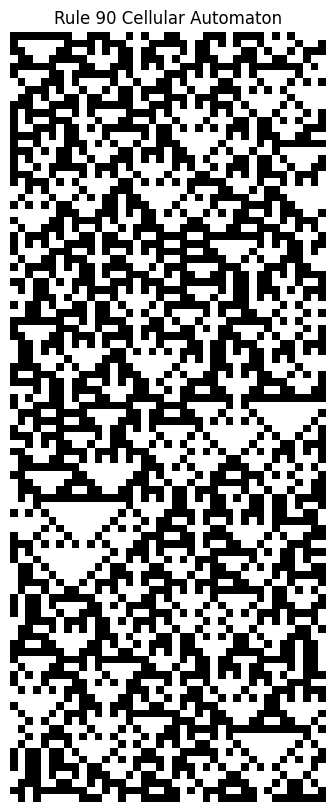

In [101]:
# Rule 90 (reducible, linear patterns)
grid_90 = elementary_ca(rule=90, width=width, steps=steps, boundary=boundary, initial_state=initial_state)
plot_ca(grid_90, 'Rule 90 Cellular Automaton')


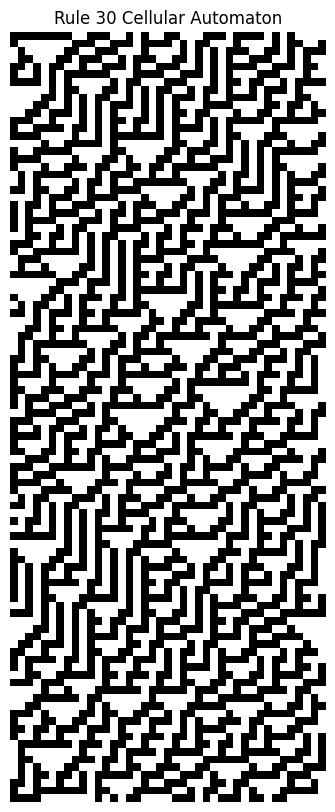

In [105]:
# Rule 30 (irreducible, chaotic patterns)
grid_30 = elementary_ca(rule=30, width=width, steps=steps, boundary=boundary, initial_state=initial_state)
plot_ca(grid_30, 'Rule 30 Cellular Automaton')